# Sequential recommendations with self-attention

You have already seen two ways to recommend films. In chapter 2, we used film genres. In chapter 3, we used the ratings of similar people. Now let's use one more clue: **the order in which a person liked films**.

If someone liked *Toy Story*, then *Aladdin*, then *The Lion King*, what might they like next? A sequential recommender looks at that trail and predicts the next item. SASRec does this with **self-attention**: each position in the history learns which earlier items matter for its prediction.

We will use the same MovieLens 100K data as the earlier chapters. To keep the example clear, a rating of 4 or 5 will count as a like. We'll draw the sequence and the attention mask, build a small SASRec, then separate two different questions: **is training settling?** and **does the ranking find a future like?**

Kang and McAuley's paper introduced SASRec in 2018: [Self-Attentive Sequential Recommendation](https://arxiv.org/abs/1808.09781).

## A film history has a direction

### a. Let's ask a different question

The previous chapters asked which films share genres, or which films similar users liked. SASRec asks: **given what this person liked in order, what might come next?**

For example, `[Toy Story, Aladdin, The Lion King]` is not just a bag of three films. It is a trail. The last film is hidden, and the recommender has to rank candidates without seeing the answer.

In [15]:
import csv
import urllib.request
import zipfile
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F

torch.manual_seed(7)
DATA_DIR = Path(".cache/ml-100k")
archive_path = DATA_DIR.parent / "ml-100k.zip"

if not DATA_DIR.exists():
    DATA_DIR.parent.mkdir(parents=True, exist_ok=True)
    if not archive_path.exists():
        print("Downloading MovieLens 100K...")
        urllib.request.urlretrieve(
            "https://files.grouplens.org/datasets/movielens/ml-100k.zip",
            archive_path,
        )
    with zipfile.ZipFile(archive_path) as archive:
        archive.extractall(DATA_DIR.parent)

### b. Let's look at the interactions

MovieLens stores one row per rating: a user, a film, a score, and a time. We'll treat ratings of **4 or 5** as positive events. Lower ratings are not called dislikes here; we simply leave them out of this first sequence example.

The time is important. We will sort each person's likes from oldest to newest, then hold back the last two. One is for checking training choices; the other is a final future event for evaluation.

In [16]:
ratings = np.loadtxt(DATA_DIR / "u.data", dtype=np.int64)
ratings = ratings[np.argsort(ratings[:, 3], kind="stable")]

with (DATA_DIR / "u.item").open(encoding="latin-1", newline="") as file:
    item_titles = {
        int(row[0]): row[1] for row in csv.reader(file, delimiter="|")
    }

original_item_ids = sorted(item_titles)
item_to_index = {item_id: index + 1 for index, item_id in enumerate(original_item_ids)}
index_to_item = {index: item_id for item_id, index in item_to_index.items()}
num_items = len(item_to_index)

liked_events = defaultdict(list)
for user_id, item_id, rating, timestamp in ratings:
    if rating >= 4:
        liked_events[int(user_id)].append((int(timestamp), item_to_index[int(item_id)]))

sessions = {
    user_id: [item_id for _, item_id in events]
    for user_id, events in liked_events.items()
    if len(events) >= 5
}
print(f"Films in catalogue: {num_items:,}")
print(f"Users with at least five likes: {len(sessions):,}")

Films in catalogue: 1,682
Users with at least five likes: 938


### c. Let's draw one prediction

Take the five most recent likes from one user. SASRec sees those five films and must guess the next liked film. The drawing below is one example from MovieLens; the dashed box is hidden while the model makes its prediction.

This picture is just the task. It is not yet the model.

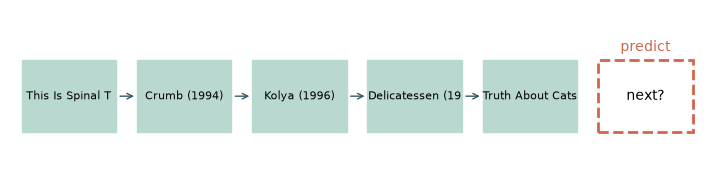

Hidden target: When the Cats Away (Chacun cherche son chat) (1996)


In [17]:
user_ids = sorted(sessions)
sample_user = user_ids[0]
sample_history = sessions[sample_user][-6:-1]
hidden_target = sessions[sample_user][-1]

fig, ax = plt.subplots(figsize=(9, 2.2))
for position, item_id in enumerate(sample_history):
    title = item_titles[index_to_item[item_id]][:16]
    ax.add_patch(plt.Rectangle((position, 0.35), 0.82, 0.38, color="#b8d8d0"))
    ax.text(position + 0.41, 0.54, title, ha="center", va="center", fontsize=8)
    if position < len(sample_history) - 1:
        ax.annotate("", (position + 1, 0.54), (position + 0.83, 0.54),
                    arrowprops={"arrowstyle": "->", "color": "#385a64"})
target_x = len(sample_history)
ax.add_patch(plt.Rectangle((target_x, 0.35), 0.82, 0.38, fill=False,
                            edgecolor="#d2644a", linestyle="--", linewidth=2))
ax.text(target_x + 0.41, 0.54, "next?", ha="center", va="center")
ax.annotate("predict", (target_x + 0.41, 0.78), ha="center", color="#d2644a")
ax.set_xlim(-0.1, target_x + 0.95)
ax.set_ylim(0.1, 1.0)
ax.axis("off")
plt.show()

print("Hidden target:", item_titles[index_to_item[hidden_target]])

## Turn histories into training examples

### a. Let's teach with the next item

For the small trail `[A, B, C, D]`, we can ask three questions:

| What the model sees | What it should predict |
| --- | --- |
| `[A]` | `B` |
| `[A, B]` | `C` |
| `[A, B, C]` | `D` |

Each history is a prefix of the same sequence. For our experiment, each user's final like is test data, the previous like is validation data, and earlier likes are training data. We never let a future item into the history used to predict it.

In [18]:
MAX_LEN = 30
def pad_right(sequence):
    sequence = sequence[-MAX_LEN:]
    return sequence + [0] * (MAX_LEN - len(sequence))

train_sequences, train_inputs, train_targets = [], [], []
validation_histories, validation_targets = [], []
test_histories, test_targets = [], []
test_histories_raw = []

for user_id in user_ids:
    sequence = sessions[user_id]
    train_sequence = sequence[:-2]
    train_sequences.append(train_sequence)
    train_inputs.append(pad_right(train_sequence[:-1]))
    train_targets.append(pad_right(train_sequence[1:]))
    validation_histories.append(pad_right(train_sequence))
    validation_targets.append(sequence[-2])
    test_history = sequence[:-1]
    test_histories_raw.append(test_history)
    test_histories.append(pad_right(test_history))
    test_targets.append(sequence[-1])

train_inputs = torch.tensor(train_inputs, dtype=torch.long)
train_targets = torch.tensor(train_targets, dtype=torch.long)
validation_histories = torch.tensor(validation_histories, dtype=torch.long)
validation_targets = torch.tensor(validation_targets, dtype=torch.long)
test_histories = torch.tensor(test_histories, dtype=torch.long)
print("Training sequences:", tuple(train_inputs.shape))
print("Validation users:", len(validation_targets))
print("Test users:", len(test_targets))

Training sequences: (938, 30)
Validation users: 938
Test users: 938


## Let each item look back

### a. No peeking at the future

Self-attention lets one position compare itself with other positions in the history. Position 3 can use positions 1 and 2 if they help. It must not use position 4: that item has not happened yet when position 3 makes its prediction.

The **causal mask** is a simple rule for this. It blocks every cell above the diagonal. Let's draw the allowed view for a five-item history.

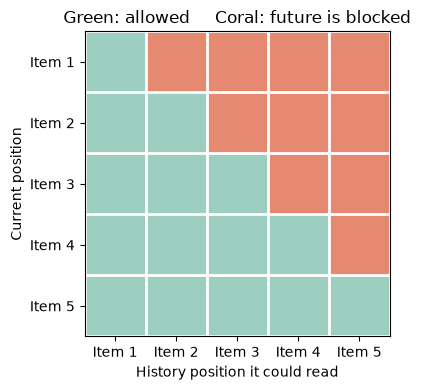

In [19]:
from matplotlib.colors import ListedColormap

mask_size = 5
blocked = np.triu(np.ones((mask_size, mask_size)), k=1)
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(blocked, cmap=ListedColormap(["#9ccfc0", "#e58a70"]), vmin=0, vmax=1)
ax.set_xticks(range(mask_size), [f"Item {i + 1}" for i in range(mask_size)])
ax.set_yticks(range(mask_size), [f"Item {i + 1}" for i in range(mask_size)])
ax.set_xlabel("History position it could read")
ax.set_ylabel("Current position")
ax.set_title("Green: allowed     Coral: future is blocked")
ax.set_xticks(np.arange(-0.5, mask_size, 1), minor=True)
ax.set_yticks(np.arange(-0.5, mask_size, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)
plt.tight_layout()
plt.show()

### b. What is self-attention doing?

At each position, SASRec asks: *which earlier items are useful for understanding this moment?* A **query** is the question, a **key** is the label each earlier item offers, and a **value** is the information that item can contribute.

The model compares a query with earlier keys. After the mask removes the future, softmax turns the remaining scores into weights. It combines the values using those weights. A multi-head layer learns several such comparisons at once.

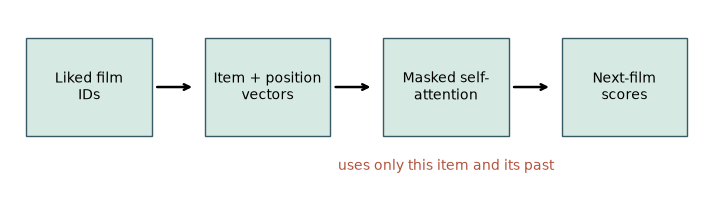

In [20]:
steps = ["Liked film\nIDs", "Item + position\nvectors",
         "Masked self-\nattention", "Next-film\nscores"]
x_positions = [0, 2.2, 4.4, 6.6]
fig, ax = plt.subplots(figsize=(9, 2.3))
for x, label in zip(x_positions, steps):
    ax.add_patch(plt.Rectangle((x, 0.45), 1.55, 0.85,
                                facecolor="#d6e9e2", edgecolor="#385a64"))
    ax.text(x + 0.775, 0.875, label, ha="center", va="center")
for x in x_positions[:-1]:
    ax.annotate("", (x + 2.08, 0.875), (x + 1.58, 0.875),
                arrowprops={"arrowstyle": "->", "lw": 1.8})
ax.text(5.175, 0.15, "uses only this item and its past", ha="center", color="#b3523e")
ax.set_xlim(-0.2, 8.4)
ax.set_ylim(0, 1.55)
ax.axis("off")
plt.show()

## Build a SASRec block

### a. Let PyTorch do the attention arithmetic

We have seen what the attention layer should do. PyTorch's `MultiheadAttention` handles the query, key, value projections and the weighted sum. We only need to provide the two rules: block future positions, and ignore padding items.

In [21]:
class CausalAttention(nn.Module):
    def __init__(self, embedding_dim, num_heads):
        super().__init__()
        self.attention = nn.MultiheadAttention(
            embedding_dim, num_heads, dropout=0.1, batch_first=True
        )

    def forward(self, values, item_ids):
        length = item_ids.size(1)
        future_mask = torch.triu(
            torch.ones(length, length, dtype=torch.bool, device=values.device),
            diagonal=1,
        )
        padding_mask = item_ids.eq(0)
        context, weights = self.attention(
            values, values, values, attn_mask=future_mask,
            key_padding_mask=padding_mask, average_attn_weights=False,
        )
        return context, weights

### b. Add the feed-forward step

The attention output is added back to its input, then normalized. A small feed-forward network processes each position independently. This gives the model two kinds of work: **look across the history**, then **refine each position's representation**.

In [22]:
class SASRecBlock(nn.Module):
    def __init__(self, embedding_dim, num_heads):
        super().__init__()
        self.attention = CausalAttention(embedding_dim, num_heads)
        self.norm1 = nn.LayerNorm(embedding_dim)
        self.feed_forward = nn.Sequential(
            nn.Linear(embedding_dim, 4 * embedding_dim),
            nn.ReLU(),
            nn.Linear(4 * embedding_dim, embedding_dim),
        )
        self.norm2 = nn.LayerNorm(embedding_dim)

    def forward(self, values, item_ids):
        context, weights = self.attention(values, item_ids)
        values = self.norm1(values + context)
        values = self.norm2(values + self.feed_forward(values))
        return values, weights

### c. Give items and positions their own vectors

An item vector tells the model *which film* appeared. A position vector tells it *where* that film appeared. We add the two vectors before attention, so the same films in a different order can produce different predictions.

After the block, the state at each position is compared with every item vector. The highest score is the model's next-item recommendation.

In [23]:
class SASRec(nn.Module):
    def __init__(self, num_items, max_len, embedding_dim=32, num_heads=2):
        super().__init__()
        self.item_embedding = nn.Embedding(num_items + 1, embedding_dim, padding_idx=0)
        self.position_embedding = nn.Embedding(max_len, embedding_dim)
        self.input_norm = nn.LayerNorm(embedding_dim)
        self.block = SASRecBlock(embedding_dim, num_heads)

    def forward(self, item_ids):
        positions = torch.arange(item_ids.size(1), device=item_ids.device)
        values = self.item_embedding(item_ids) + self.position_embedding(positions)
        values = self.input_norm(values)
        return self.block(values, item_ids)

    def score_all(self, states):
        return states @ self.item_embedding.weight[1:].T

### d. Let's inspect the shapes

For a batch of histories, the encoder produces one vector per position. If we then compare each vector with the catalogue, we get one score per possible film.

The dimensions are worth checking once: `(users, positions, embedding size)` for the hidden states, then `(users, positions, films)` for the scores.

In [24]:
model = SASRec(num_items, MAX_LEN, embedding_dim=32, num_heads=2)
example_inputs = train_inputs[:2]
with torch.no_grad():
    hidden_states, attention_weights = model(example_inputs)
    item_scores = model.score_all(hidden_states)

print("Histories:      ", tuple(example_inputs.shape))
print("Hidden states:  ", tuple(hidden_states.shape))
print("Attention maps: ", tuple(attention_weights.shape))
print("Item scores:    ", tuple(item_scores.shape))

Histories:       (2, 30)
Hidden states:   (2, 30, 32)
Attention maps:  (2, 2, 30, 30)
Item scores:     (2, 30, 1682)


### e. What should the scores learn?

The state at a position is compared with an item's embedding using a dot product. These are ranking scores, not star ratings or probabilities.

The next liked film is a **positive** example. We draw a different film as a **sampled negative**. The model should score the positive higher than the negative:

$$
\\mathcal{L} = \\operatorname{BCE}(s^+, 1) + \\operatorname{BCE}(s^-, 0)
$$

Padding positions have no target, so we leave them out of the loss. This is a teaching sampler: an unobserved film is not necessarily disliked, so real systems need careful negative sampling.

In [25]:
negative_rng = np.random.default_rng(21)
all_item_ids = np.arange(1, num_items + 1)
negative_rows, validation_negatives = [], []

for user_id, train_sequence, target_row in zip(
    user_ids, train_sequences, train_targets.tolist()
):
    known = set(train_sequence)
    choices = np.setdiff1d(all_item_ids, list(known))
    negative_row = [
        0 if target == 0 else int(negative_rng.choice(choices))
        for target in target_row
    ]
    negative_rows.append(negative_row)

    validation_target = sessions[user_id][-2]
    validation_choices = np.setdiff1d(choices, [validation_target])
    validation_negatives.append(int(negative_rng.choice(validation_choices)))

negative_targets = torch.tensor(negative_rows, dtype=torch.long)
validation_negatives = torch.tensor(validation_negatives, dtype=torch.long)
print("Negative samples:", tuple(negative_targets.shape))

Negative samples: (938, 30)


## Train the sequence model

### a. Let's learn from earlier sessions

One update follows the same loop as other PyTorch models: clear the old gradients, calculate the loss, backpropagate, then update the parameters. We repeat this over training histories and watch a **loss curve**.

The validation history is kept separate from training. It gives us a check on examples the optimizer did not train on.

In [26]:
def sampled_bce(model, inputs, targets, negatives):
    states, _ = model(inputs)
    valid = targets.ne(0)
    if targets.ndim == 1:
        last_positions = inputs.ne(0).sum(dim=1) - 1
        rows = torch.arange(len(inputs))
        states = states[rows, last_positions]
    else:
        states = states[valid]
    targets = targets[valid]
    negatives = negatives[valid]

    positive = (states * model.item_embedding(targets)).sum(dim=-1)
    negative = (states * model.item_embedding(negatives)).sum(dim=-1)
    positive_loss = F.binary_cross_entropy_with_logits(
        positive, torch.ones_like(positive)
    )
    negative_loss = F.binary_cross_entropy_with_logits(
        negative, torch.zeros_like(negative)
    )
    return positive_loss + negative_loss

In [27]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
train_losses, validation_losses = [], []
batch_size = 128

for epoch in range(12):
    model.train()
    order = torch.randperm(len(train_inputs))
    batch_losses = []
    for start in range(0, len(order), batch_size):
        rows = order[start : start + batch_size]
        optimizer.zero_grad()
        loss = sampled_bce(
            model, train_inputs[rows], train_targets[rows], negative_targets[rows]
        )
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(float(np.mean(batch_losses)))

    model.eval()
    with torch.no_grad():
        validation_losses.append(
            sampled_bce(
                model, validation_histories, validation_targets, validation_negatives
            ).item()
        )

print(f"Last training loss:   {train_losses[-1]:.3f}")
print(f"Last validation loss: {validation_losses[-1]:.3f}")

Last training loss:   0.996
Last validation loss: 1.121


### b. Watch training, not recommendation quality

This chart answers only a training question: **is the objective getting smaller on training examples, and does validation behave similarly?** It does not tell us whether the top recommendations are useful. We'll measure that separately on held-out future likes.

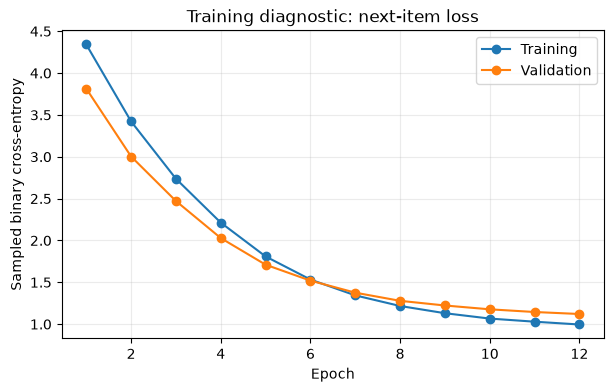

In [28]:
epochs = np.arange(1, len(train_losses) + 1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epochs, train_losses, marker="o", label="Training")
ax.plot(epochs, validation_losses, marker="o", label="Validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("Sampled binary cross-entropy")
ax.set_title("Training diagnostic: next-item loss")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

### c. Let's see what the model attends to

For one short history, the heatmap shows how much each current position reads from each earlier position. Future cells stay at zero because of the causal mask. This is a view inside the model, not a performance measure.

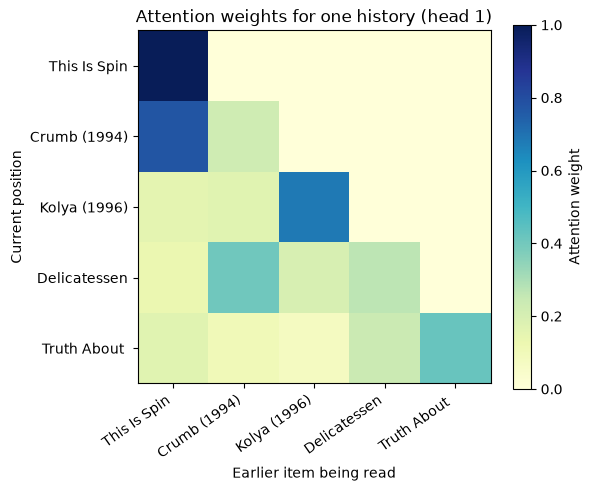

In [29]:
attention_input = torch.tensor([pad_right(sample_history)], dtype=torch.long)
model.eval()
with torch.no_grad():
    _, weights = model(attention_input)
attention = weights[0, 0, :len(sample_history), :len(sample_history)].cpu().numpy()
labels = [item_titles[index_to_item[item]][:12] for item in sample_history]

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(attention, cmap="YlGnBu", vmin=0)
ax.set_xticks(range(len(labels)), labels, rotation=35, ha="right")
ax.set_yticks(range(len(labels)), labels)
ax.set_xlabel("Earlier item being read")
ax.set_ylabel("Current position")
ax.set_title("Attention weights for one history (head 1)")
fig.colorbar(image, ax=ax, label="Attention weight")
plt.tight_layout()
plt.show()

## Does it recommend the next film?

Training loss and recommendation quality are different questions, so we will use a **different test and a different graph** here.

For each user, the final liked film was not used for training. We encode the history available before that event, rank unseen films, and check whether the hidden film appears in the top 10. We compare SASRec with a **most-popular** baseline built from training likes only.

Our metric is **HitRate@10**: the fraction of test users whose hidden film appears in the ten recommendations. Since there is one test film per user, this is also Recall@10 for this test. This offline replay does not prove a user would click or watch a recommendation, but it checks whether the model ranks a later like above other candidates.

In [30]:
train_item_counts = np.bincount(
    np.concatenate(train_sequences), minlength=num_items + 1
 )
known_catalogue = train_item_counts[1:] > 0
test_target_array = np.asarray(test_targets)
test_rows = np.flatnonzero([train_item_counts[item] > 0 for item in test_targets])

model.eval()
with torch.no_grad():
    test_states, _ = model(test_histories)
    lengths = test_histories.ne(0).sum(dim=1)
    user_rows = torch.arange(len(test_histories))
    last_states = test_states[user_rows, lengths - 1]
    sasrec_scores = model.score_all(last_states).cpu().numpy()

popular_scores = np.tile(train_item_counts[1:], (len(user_ids), 1)).astype(float)
for row, history in enumerate(test_histories_raw):
    seen_columns = np.asarray(history, dtype=int) - 1
    sasrec_scores[row, seen_columns] = -np.inf
    popular_scores[row, seen_columns] = -np.inf
    sasrec_scores[row, ~known_catalogue] = -np.inf
    popular_scores[row, ~known_catalogue] = -np.inf

top_k = 10
sasrec_top_k = np.argsort(-sasrec_scores, axis=1)[:, :top_k]
popular_top_k = np.argsort(-popular_scores, axis=1)[:, :top_k]
target_columns = test_target_array - 1
sasrec_hit_rate = np.mean([
    target_columns[row] in sasrec_top_k[row] for row in test_rows
 ])
popular_hit_rate = np.mean([
    target_columns[row] in popular_top_k[row] for row in test_rows
 ])

print(f"Warm-start test users: {len(test_rows):,}")
print(f"Popularity HitRate@{top_k}: {popular_hit_rate:.3f}")
print(f"SASRec HitRate@{top_k}:      {sasrec_hit_rate:.3f}")

Warm-start test users: 923
Popularity HitRate@10: 0.082
SASRec HitRate@10:      0.029


In [ ]:
method_names = ["Most popular", "SASRec"]
hit_rates = [popular_hit_rate, sasrec_hit_rate]
colors = ["#d9a45b", "#4f9887"]
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(method_names, hit_rates, color=colors, width=0.58)
ax.set_ylabel(f"HitRate@{top_k}")
ax.set_ylim(0, max(hit_rates) * 1.25 if max(hit_rates) else 1)
ax.set_title("Ranking performance on held-out future likes")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
for bar, value in zip(bars, hit_rates):
    ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.3f}",
            ha="center", va="bottom")
plt.tight_layout()
plt.show()

The loss chart and the HitRate chart answer different questions. Lower training loss means the model fits its observed next-item examples. Higher HitRate@10 means it found more of the users' final held-out likes near the top of the list.

Popularity is a useful baseline, not an embarrassing one. If SASRec does not beat it on this split, that is a result to investigate: perhaps the model needs more history, a different training setup, or a longer evaluation. We should report what happened, not assume a neural model must win.

This is still an offline replay. MovieLens records ratings, not every film a person was shown, so HitRate@10 measures whether a future like was retrieved; it does not prove the recommendation caused a click.

## Your turn

1. Compare the attention heatmap for one head with another head. Do they focus on the same earlier films?
2. Train for fewer and more epochs. Can training loss keep falling while validation loss stops improving?
3. Compare HitRate@5, HitRate@10, and HitRate@20 against the popularity baseline.
4. Change `MAX_LEN`. Which older likes disappear from the model's view?

## In summary

- SASRec predicts the next liked item from an ordered history.
- Item embeddings describe films; position embeddings let the model distinguish order.
- Causal attention combines useful earlier items without looking into the future.
- Training loss measures fit to next-item examples; held-out HitRate measures ranking performance. They need separate diagnostics.
- Popularity provides a baseline, and a chronological holdout keeps the final future like out of training.